In [1]:
import os
import json
import subprocess
from pathlib import Path

In [2]:
# Configuracion de descarga
download_url = "https://www.kaggle.com/api/v1/datasets/download/shreyapmaher/fruits-dataset-images"
zip_name = "fruits-dataset-images.zip"
data_dir = Path("data")
data_dir.mkdir(parents=True, exist_ok=True)

In [3]:
zip_path = data_dir / zip_name
subprocess.run([
    'curl', '-L',
    '-o', str(zip_path),
    download_url
], check=True)

subprocess.run([
    'unzip', '-o', str(zip_path), '-d', str(data_dir)
], check=True)

if zip_path.exists():
    zip_path.unlink()

print('Dataset descargado y descomprimido en:', data_dir.resolve())

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  204M  100  204M    0     0  15.4M      0  0:00:13  0:00:13 --:--:-- 18.0M


Archive:  data/fruits-dataset-images.zip
  inflating: data/images/apple fruit/Image_1.jpg  
  inflating: data/images/apple fruit/Image_10.jpg  
  inflating: data/images/apple fruit/Image_11.jpg  
  inflating: data/images/apple fruit/Image_12.jpg  
  inflating: data/images/apple fruit/Image_13.png  
  inflating: data/images/apple fruit/Image_14.png  
  inflating: data/images/apple fruit/Image_15.jpg  
  inflating: data/images/apple fruit/Image_16.jpg  
  inflating: data/images/apple fruit/Image_17.jpeg  
  inflating: data/images/apple fruit/Image_18.jpg  
  inflating: data/images/apple fruit/Image_19.jpg  
  inflating: data/images/apple fruit/Image_2.jpg  
  inflating: data/images/apple fruit/Image_20.jpg  
  inflating: data/images/apple fruit/Image_21.jpg  
  inflating: data/images/apple fruit/Image_22.jpg  
  inflating: data/images/apple fruit/Image_23.png  
  inflating: data/images/apple fruit/Image_24.jpg  
  inflating: data/images/apple fruit/Image_25.jpg  
  inflating: data/images

Total de imagenes: 359

Numero de imagenes por categoria:
label
banana fruit        40
apple fruit         40
chickoo fruit       40
grapes fruit        40
strawberry fruit    40
orange fruit        40
cherry fruit        40
kiwi fruit          40
mango fruit         39
Name: count, dtype: int64


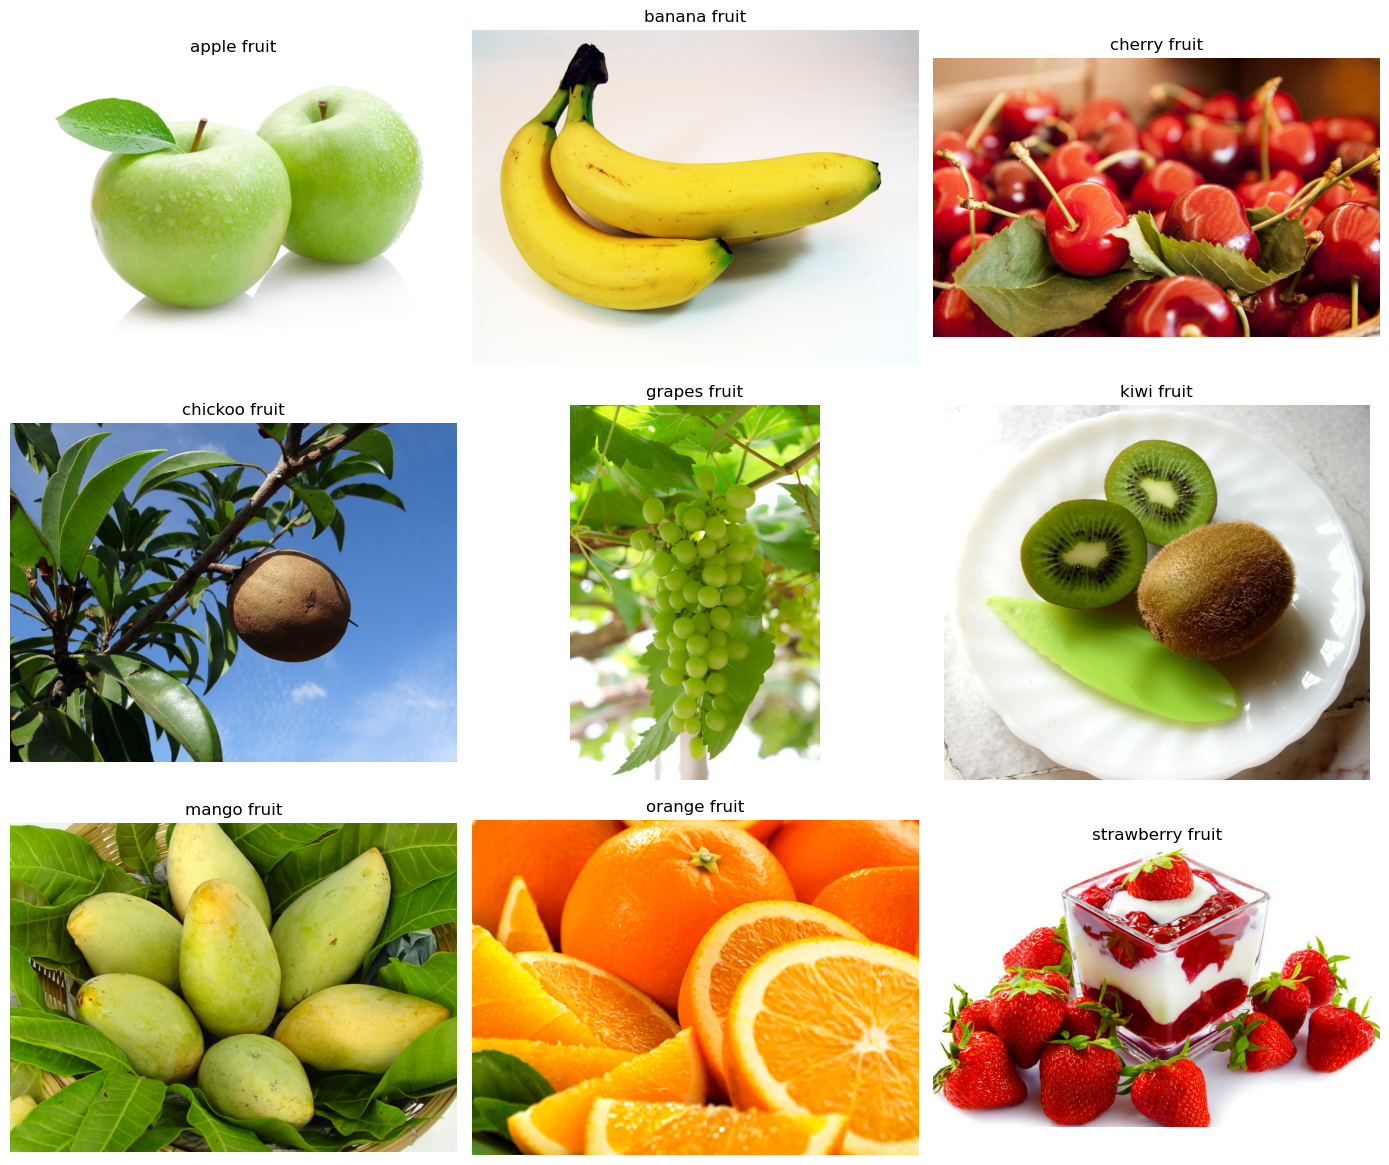

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Directorio base con las clases de frutas
base_dir = 'data/images'

filepaths = []
labels = []

# Recorrer cada carpeta de clase
for label in os.listdir(base_dir):
    label_path = os.path.join(base_dir, label)
    if os.path.isdir(label_path):
        for file in os.listdir(label_path):
            ext = os.path.splitext(file)[1].lower()
            if ext in ['.png', '.jpg', '.jpeg']:
                filepaths.append(os.path.join(label_path, file))
                labels.append(label)

# Crear DataFrame con las rutas y etiquetas
data_df = pd.DataFrame({'filepath': filepaths, 'label': labels})

# Mostrar conteo total y por categoria
print('Total de imagenes:', len(data_df))
print('\nNumero de imagenes por categoria:')
print(data_df['label'].value_counts())

# Mostrar una imagen por categoria
categorias = sorted(data_df['label'].unique())
num_muestras = len(categorias)

cols = 3
rows = int((num_muestras + cols - 1) / cols)
plt.figure(figsize=(14, 4 * rows))
for i, categoria in enumerate(categorias[:num_muestras]):
    img_path = data_df[data_df['label'] == categoria].iloc[0]['filepath']
    img = mpimg.imread(img_path)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(f'{categoria}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

# Dividir el dataset en 70% entrenamiento y 30% (validación + prueba)
train_df, test_val_df = train_test_split(
    data_df, test_size=0.3, random_state=42, stratify=data_df['label']
)

# A partir del 30% restante, dividir en 2/3 para validación y 1/3 para prueba (~20% y ~10% del total, respectivamente)
val_df, test_df = train_test_split(
    test_val_df, test_size=(1/3), random_state=42, stratify=test_val_df['label']
)

print("Entrenamiento:", len(train_df))
print("Validación:", len(val_df))
print("Prueba:", len(test_df))

Entrenamiento: 251
Validación: 72
Prueba: 36


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True
)

test_val_datagen = ImageDataGenerator(
    rescale=1./255
)

img_size = (128, 128)
batch_size = 32

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=img_size, batch_size=batch_size,
    class_mode='categorical'
)

val_gen = test_val_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=img_size, batch_size=batch_size,
    class_mode='categorical', shuffle=False
)

test_gen = test_val_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=img_size, batch_size=batch_size,
    class_mode='categorical', shuffle=False
)

# Diccionario con nombre de clase -> indice
labels_map = train_gen.class_indices

# Invertimos el diccionario para tener indice -> nombre de clase
idx_to_class = {v: k for k, v in labels_map.items()}
class_names = [idx_to_class[i] for i in sorted(idx_to_class)]

print('\nCategorias reconocidas:')
for idx in sorted(idx_to_class):
    print(f"  Clase {idx}: '{idx_to_class[idx]}'")

num_classes = len(labels_map)
print('Numero de clases:', num_classes)

Found 251 validated image filenames belonging to 9 classes.
Found 72 validated image filenames belonging to 9 classes.
Found 36 validated image filenames belonging to 9 classes.

Categorias reconocidas:
  Clase 0: 'apple fruit'
  Clase 1: 'banana fruit'
  Clase 2: 'cherry fruit'
  Clase 3: 'chickoo fruit'
  Clase 4: 'grapes fruit'
  Clase 5: 'kiwi fruit'
  Clase 6: 'mango fruit'
  Clase 7: 'orange fruit'
  Clase 8: 'strawberry fruit'
Numero de clases: 9


In [7]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model_scratch = Sequential([
    # Primer bloque convolucional
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    # Segundo bloque
    Conv2D(64, (3,3), activation='relu'),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    # Tercer bloque
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    # Aplanamiento y capas densas
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

model_scratch.summary()

/opt/anaconda3/envs/notebook_1/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 124, 124, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 58, 58, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 27, 27, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     5,538,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,679,785 (21.67 MB)

 Trainable params: 5,679,785 (21.67 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

model_scratch.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_scratch = [
    ModelCheckpoint('best_model_scratch.keras', save_best_only=True, monitor='val_loss', mode='min'),
    EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='min')
]

In [9]:
import tensorflow as tf

epochs_scratch = 15
with tf.device('/device:GPU:0'):
    history_scratch = model_scratch.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs_scratch,
        callbacks=callbacks_scratch
    )

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 888ms/step - accuracy: 0.1633 - loss: 2.1800 - val_accuracy: 0.2222 - val_loss: 1.9478 - learning_rate: 0.0010
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 736ms/step - accuracy: 0.3426 - loss: 1.7443 - val_accuracy: 0.3056 - val_loss: 1.8676 - learning_rate: 0.0010
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 703ms/step - accuracy: 0.4183 - loss: 1.5153 - val_accuracy: 0.4306 - val_loss: 1.5393 - learning_rate: 0.0010
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 709ms/step - accuracy: 0.4422 - loss: 1.3436 - val_accuracy: 0.4444 - val_loss: 1.6447 - learning_rate: 0.0010
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 715ms/step - accuracy: 0.4821 - loss: 1.2330 - val_accuracy: 0.3750 - val_loss: 1.5473 - learning_rate: 0.0010
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 711ms/step - accuracy: 0.5538 - loss: 1.1428 - val_accuracy: 0.5000 - val_loss: 1.6339 - learning_rate: 0.0010
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 723ms/step - accuracy: 0.5737 - loss: 1.0852 - val_accuracy: 

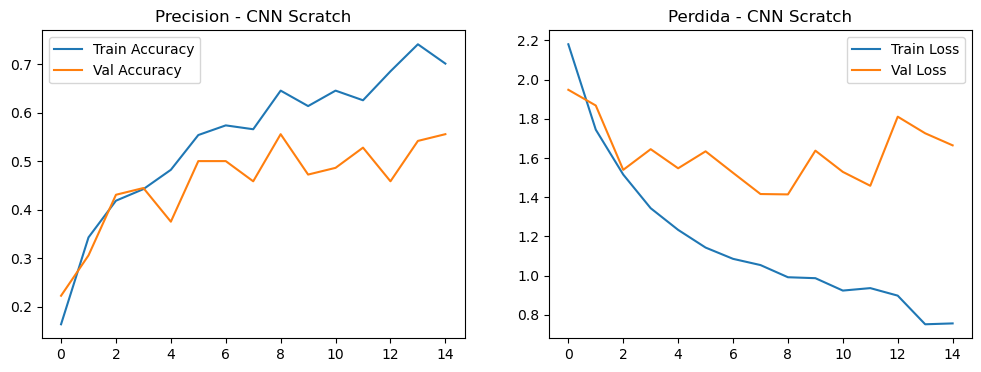

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step 


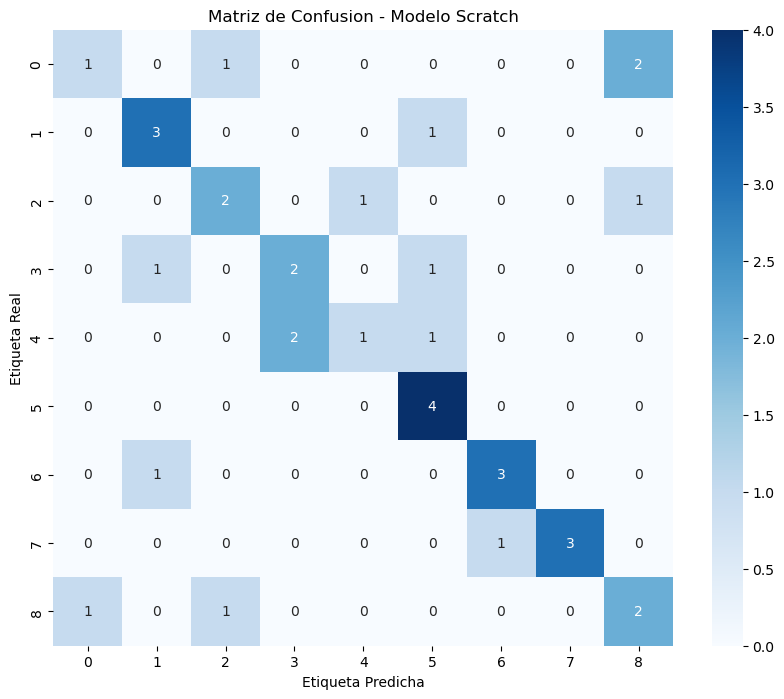

Reporte de Clasificacion - Modelo Scratch

                  precision    recall  f1-score   support

     apple fruit       0.50      0.25      0.33         4
    banana fruit       0.60      0.75      0.67         4
    cherry fruit       0.50      0.50      0.50         4
   chickoo fruit       0.50      0.50      0.50         4
    grapes fruit       0.50      0.25      0.33         4
      kiwi fruit       0.57      1.00      0.73         4
     mango fruit       0.75      0.75      0.75         4
    orange fruit       1.00      0.75      0.86         4
strawberry fruit       0.40      0.50      0.44         4

        accuracy                           0.58        36
       macro avg       0.59      0.58      0.57        36
    weighted avg       0.59      0.58      0.57        36



In [10]:
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# Graficar la historia de entrenamiento
acc = history_scratch.history['accuracy']
val_acc = history_scratch.history['val_accuracy']
loss = history_scratch.history['loss']
val_loss = history_scratch.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Val Accuracy')
plt.legend()
plt.title('Precision - CNN Scratch')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.legend()
plt.title('Perdida - CNN Scratch')
plt.show()

# Cargar el mejor modelo y evaluar
best_scratch_model = load_model('best_model_scratch.keras')
test_gen.reset()
preds_scratch = best_scratch_model.predict(test_gen, verbose=1)
y_pred_scratch = np.argmax(preds_scratch, axis=1)
y_true = test_gen.classes

cm_scratch = confusion_matrix(y_true, y_pred_scratch)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_scratch, annot=True, fmt='d', cmap=plt.cm.Blues)
plt.title('Matriz de Confusion - Modelo Scratch')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()

print('Reporte de Clasificacion - Modelo Scratch')
print()
print(classification_report(y_true, y_pred_scratch, target_names=class_names, zero_division=0))

Transfer Learning con Modelos Fundacionales

In [11]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Cargar VGG16 pre-entrenado en ImageNet, sin incluir la parte superior
base_model_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Congelar todas las capas del modelo base para no reentrenarlas
for layer in base_model_vgg.layers:
    layer.trainable = False

# Construir el modelo de transfer learning
model_vgg = Sequential([
    base_model_vgg,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

# Mostrar la arquitectura del modelo
model_vgg.summary()

# Compilar el modelo
model_vgg.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Definir callbacks para guardar el mejor modelo, detener tempranamente y reducir la tasa de aprendizaje
callbacks_vgg = [
    ModelCheckpoint('best_model_vgg.keras', save_best_only=True, monitor='val_loss', mode='min'),
    EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='min')
]

# Entrenar el modelo de transfer learning
epochs_vgg = 15
with tf.device('/device:GPU:0'):
    history_vgg = model_vgg.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs_vgg,
        callbacks=callbacks_vgg
    )

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,513 (56.39 MB)

 Trainable params: 66,825 (261.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.1633 - loss: 2.2892 - val_accuracy: 0.2639 - val_loss: 2.0692 - learning_rate: 0.0010
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 864ms/step - accuracy: 0.3028 - loss: 1.9888 - val_accuracy: 0.4583 - val_loss: 1.8882 - learning_rate: 0.0010
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 880ms/step - accuracy: 0.4821 - loss: 1.7693 - val_accuracy: 0.4861 - val_loss: 1.7360 - learning_rate: 0.0010
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 847ms/step - accuracy: 0.5857 - loss: 1.5470 - val_accuracy: 0.4861 - val_loss: 1.6143 - learning_rate: 0.0010
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 831ms/step - accuracy: 0.6295 - loss: 1.4223 - val_accuracy: 0.5278 - val_loss: 1.5171 - learning_rate: 0.0010
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 846ms/step - accuracy: 0.6733 - loss: 1.2851 - val_accuracy: 0.5833 - val_loss: 1.4238 - learning_rate: 0.0010
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 891ms/step - accuracy: 0.7012 - loss: 1.1726 - val_accuracy: 0.5

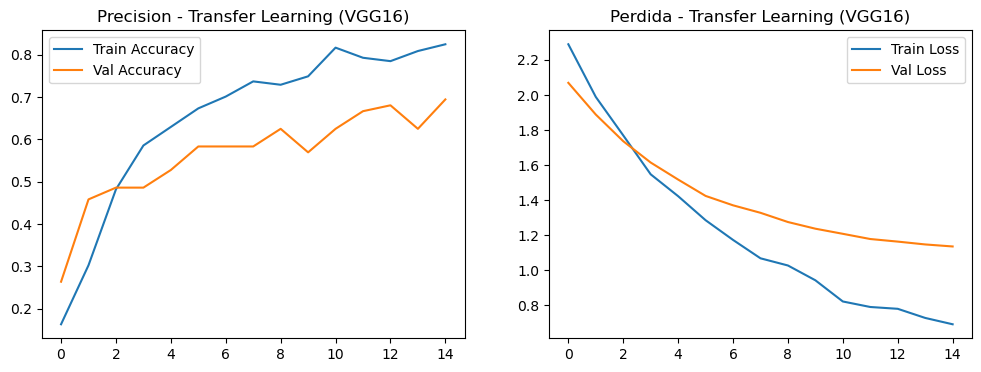

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step


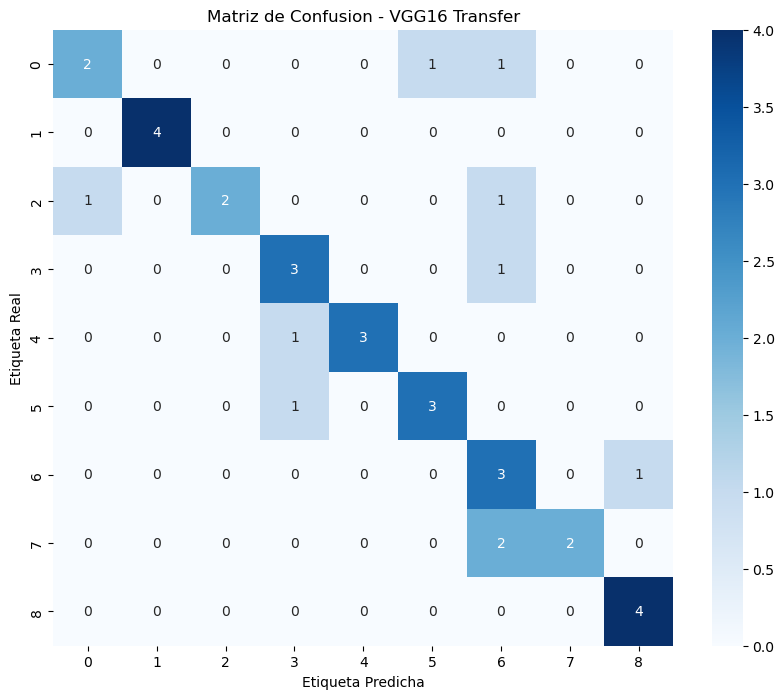

Reporte de Clasificacion - Transfer Learning (VGG16)

                  precision    recall  f1-score   support

     apple fruit       0.67      0.50      0.57         4
    banana fruit       1.00      1.00      1.00         4
    cherry fruit       1.00      0.50      0.67         4
   chickoo fruit       0.60      0.75      0.67         4
    grapes fruit       1.00      0.75      0.86         4
      kiwi fruit       0.75      0.75      0.75         4
     mango fruit       0.38      0.75      0.50         4
    orange fruit       1.00      0.50      0.67         4
strawberry fruit       0.80      1.00      0.89         4

        accuracy                           0.72        36
       macro avg       0.80      0.72      0.73        36
    weighted avg       0.80      0.72      0.73        36



In [12]:
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# Graficar la historia de entrenamiento
acc_vgg = history_vgg.history['accuracy']
val_acc_vgg = history_vgg.history['val_accuracy']
loss_vgg = history_vgg.history['loss']
val_loss_vgg = history_vgg.history['val_loss']
epochs_range_vgg = range(len(acc_vgg))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_vgg, acc_vgg, label='Train Accuracy')
plt.plot(epochs_range_vgg, val_acc_vgg, label='Val Accuracy')
plt.legend()
plt.title('Precision - Transfer Learning (VGG16)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range_vgg, loss_vgg, label='Train Loss')
plt.plot(epochs_range_vgg, val_loss_vgg, label='Val Loss')
plt.legend()
plt.title('Perdida - Transfer Learning (VGG16)')
plt.show()

# Cargar el mejor modelo y evaluar
best_vgg_model = load_model('best_model_vgg.keras')
test_gen.reset()
preds_vgg = best_vgg_model.predict(test_gen, verbose=1)
y_pred_vgg = np.argmax(preds_vgg, axis=1)

cm_vgg = confusion_matrix(y_true, y_pred_vgg)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap=plt.cm.Blues)
plt.title('Matriz de Confusion - VGG16 Transfer')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()

print('Reporte de Clasificacion - Transfer Learning (VGG16)')
print()
print(classification_report(y_true, y_pred_vgg, target_names=class_names, zero_division=0))

Comparación entre modelo Scratch y el modelo VGG16:

¿Cuál obtuvo mejor precisión y cuál converge más rápido?

El modelo basado en **transfer learning con VGG16** presenta un mejor desempeño en comparación con la CNN entrenada desde cero, ya que alcanza una mayor precisión en validación (0.72) comparado al CNN desde cero (0.58) y muestra un comportamiento más estable a lo largo de las épocas. Además, converge más rápido, dado que en las primeras 4–5 épocas ya se aproxima a su rendimiento final, mientras que la CNN desde cero requiere más iteraciones y presenta mayor variabilidad.

¿Fue necesario más tiempo para entrenar la red desde cero?

No, los tiempos de entrenamiento fueron muy similares. Sin embargo, el transfer learning aporta una ventaja importante, ya que no es necesario entrenar desde cero todas las capas del modelo. En el caso de VGG16, las primeras capas ya contienen pesos preentrenados que capturan características generales (como bordes y texturas), por lo que solo se requiere ajustar las capas finales adaptadas a la nueva tarea. Esto permite que el modelo converja más rápido y de manera más estable, aunque el tiempo total de ejecución por época puede ser comparable al de una red entrenada desde cero.

¿Por qué la arquitectura pre-entrenada podría ofrecer ventajas cuando el dataset de destino no es tan grande?

Una arquitectura preentrenada, como VGG16, ofrece ventajas cuando el dataset de destino es pequeño porque ya ha aprendido previamente características visuales generales a partir de grandes conjuntos de datos (como bordes, texturas y formas). Esto permite reutilizar ese conocimiento y evitar entrenar el modelo desde cero, lo cual requeriría muchos más datos para lograr un buen desempeño. Como resultado, el modelo necesita menos ejemplos para aprender la tarea específica, converge más rápido y reduce el riesgo de sobreajuste, logrando una mejor capacidad de generalización incluso con datasets limitados.


Experimentación con Otros Modelos Fundacionales:

In [16]:
# Preprocesamiento
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input  # 🔥 CLAVE

# -------------------------
# DATA AUGMENTATION (TRAIN)
# -------------------------
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # ❌ quitar rescale
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# -------------------------
# VALIDATION / TEST
# -------------------------
test_val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input  # ❌ quitar rescale
)

# -------------------------
# PARÁMETROS
# -------------------------
img_size = (224, 224)  # 🔥 MUY IMPORTANTE
batch_size = 32

# -------------------------
# GENERATORS
# -------------------------
train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='label',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = test_val_datagen.flow_from_dataframe(
    val_df,
    x_col='filepath',
    y_col='label',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_gen = test_val_datagen.flow_from_dataframe(
    test_df,
    x_col='filepath',
    y_col='label',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# -------------------------
# CLASES
# -------------------------
labels_map = train_gen.class_indices
idx_to_class = {v: k for k, v in labels_map.items()}
class_names = [idx_to_class[i] for i in sorted(idx_to_class)]

print('\nCategorias reconocidas:')
for idx in sorted(idx_to_class):
    print(f"  Clase {idx}: '{idx_to_class[idx]}'")

num_classes = len(labels_map)
print('Numero de clases:', num_classes)

Found 251 validated image filenames belonging to 9 classes.
Found 72 validated image filenames belonging to 9 classes.
Found 36 validated image filenames belonging to 9 classes.

Categorias reconocidas:
  Clase 0: 'apple fruit'
  Clase 1: 'banana fruit'
  Clase 2: 'cherry fruit'
  Clase 3: 'chickoo fruit'
  Clase 4: 'grapes fruit'
  Clase 5: 'kiwi fruit'
  Clase 6: 'mango fruit'
  Clase 7: 'orange fruit'
  Clase 8: 'strawberry fruit'
Numero de clases: 9


In [17]:
# Modelo fundacional : ResNet50
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

# -------------------------
# 1. MODELO BASE
# -------------------------
base_model_resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Congelar capas
for layer in base_model_resnet.layers:
    layer.trainable = False

# -------------------------
# 2. HEAD PERSONALIZADO
# -------------------------
model_resnet = Sequential([
    base_model_resnet,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

# -------------------------
# 3. COMPILAR
# -------------------------
model_resnet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet.summary()

# -------------------------
# 4. CALLBACKS
# -------------------------
callbacks_resnet = [
    ModelCheckpoint('best_model_resnet.keras', save_best_only=True, monitor='val_loss', mode='min'),
    EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='min')
]

# -------------------------
# 5. ENTRENAMIENTO
# -------------------------
epochs_resnet = 15

with tf.device('/device:GPU:0'):
    history_resnet = model_resnet.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs_resnet,
        callbacks=callbacks_resnet
    )

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,851,145 (90.98 MB)

 Trainable params: 263,433 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.4263 - loss: 1.8544 - val_accuracy: 0.6528 - val_loss: 1.0434 - learning_rate: 0.0010
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 881ms/step - accuracy: 0.7968 - loss: 0.6756 - val_accuracy: 0.8056 - val_loss: 0.5528 - learning_rate: 0.0010
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 870ms/step - accuracy: 0.8805 - loss: 0.3440 - val_accuracy: 0.8611 - val_loss: 0.4253 - learning_rate: 0.0010
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 905ms/step - accuracy: 0.9402 - loss: 0.2261 - val_accuracy: 0.8889 - val_loss: 0.3384 - learning_rate: 0.0010
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 908ms/step - accuracy: 0.9562 - loss: 0.1528 - val_accuracy: 0.8611 - val_loss: 0.3046 - learning_rate: 0.0010
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 826ms/step - accuracy: 0.9761 - loss: 0.1104 - val_accuracy: 0.8889 - val_loss: 0.3180 - learning_rate: 0.0010
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 934ms/step - accuracy: 0.9841 - loss: 0.0665 - val_accuracy: 0.

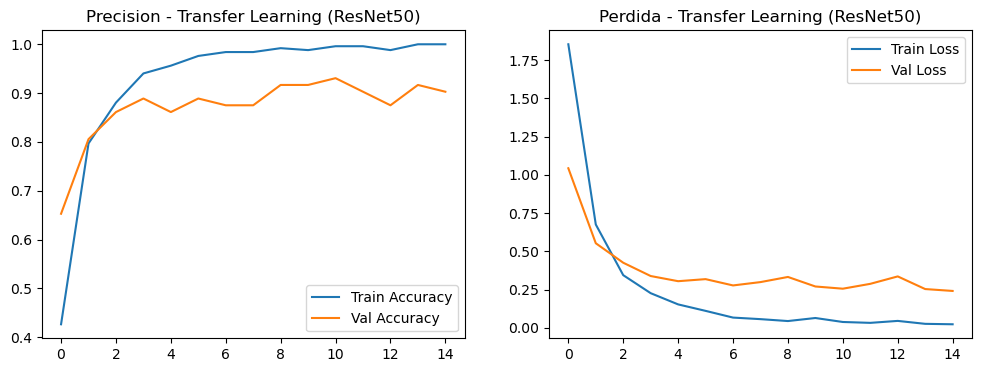

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 774ms/step


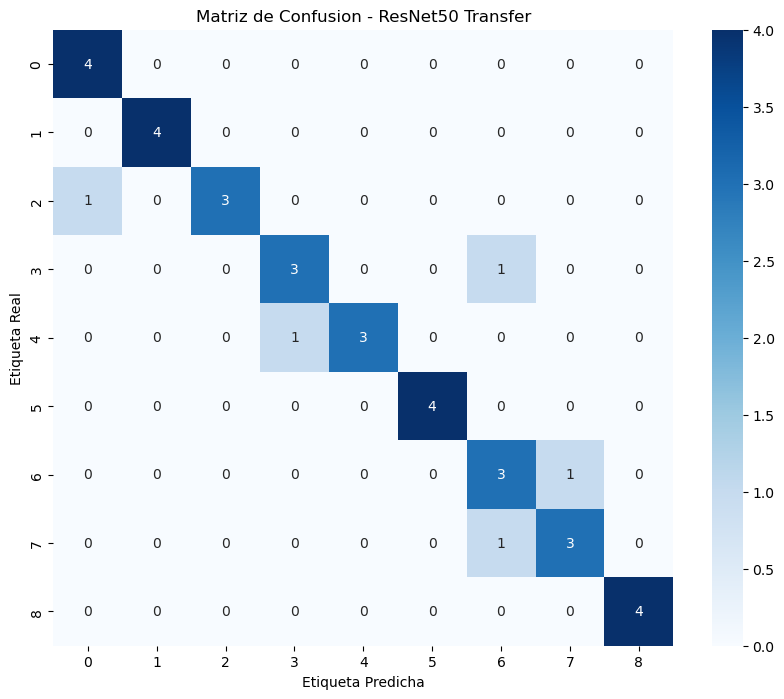

Reporte de Clasificacion - Transfer Learning (ResNet50)

                  precision    recall  f1-score   support

     apple fruit       0.80      1.00      0.89         4
    banana fruit       1.00      1.00      1.00         4
    cherry fruit       1.00      0.75      0.86         4
   chickoo fruit       0.75      0.75      0.75         4
    grapes fruit       1.00      0.75      0.86         4
      kiwi fruit       1.00      1.00      1.00         4
     mango fruit       0.60      0.75      0.67         4
    orange fruit       0.75      0.75      0.75         4
strawberry fruit       1.00      1.00      1.00         4

        accuracy                           0.86        36
       macro avg       0.88      0.86      0.86        36
    weighted avg       0.88      0.86      0.86        36



In [18]:
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# Graficar la historia de entrenamiento
acc_resnet = history_resnet.history['accuracy']
val_acc_resnet = history_resnet.history['val_accuracy']
loss_resnet = history_resnet.history['loss']
val_loss_resnet = history_resnet.history['val_loss']
epochs_range_resnet = range(len(acc_resnet))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_resnet, acc_resnet, label='Train Accuracy')
plt.plot(epochs_range_resnet, val_acc_resnet, label='Val Accuracy')
plt.legend()
plt.title('Precision - Transfer Learning (ResNet50)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range_resnet, loss_resnet, label='Train Loss')
plt.plot(epochs_range_resnet, val_loss_resnet, label='Val Loss')
plt.legend()
plt.title('Perdida - Transfer Learning (ResNet50)')
plt.show()

# Cargar el mejor modelo y evaluar
best_vgg_model = load_model('best_model_resnet.keras')
test_gen.reset()
preds_resnet = best_vgg_model.predict(test_gen, verbose=1)
y_pred_resnet = np.argmax(preds_resnet, axis=1)

cm_resnet = confusion_matrix(y_true, y_pred_resnet)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap=plt.cm.Blues)
plt.title('Matriz de Confusion - ResNet50 Transfer')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()

print('Reporte de Clasificacion - Transfer Learning (ResNet50)')
print()
print(classification_report(y_true, y_pred_resnet, target_names=class_names, zero_division=0))

El modelo basado en ResNet50 presentó un desempeño superior al obtenido con VGG16, alcanzando una mayor precisión (accuracy ≈ 0.86 frente a ≈ 0.72) y una mejor capacidad de generalización. Esta mejora se debe a su arquitectura más profunda con conexiones residuales, así como al uso adecuado del preprocesamiento específico requerido por el modelo (incluyendo el ajuste del tamaño de entrada a 224×224 y la normalización mediante *preprocess_input*), lo que permitió aprovechar de manera más efectiva el conocimiento previamente aprendido en ImageNet.
